In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.metrics import (roc_auc_score, roc_curve, 
                             confusion_matrix, classification_report,
                             precision_recall_curve, average_precision_score)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")

All libraries imported!


In [2]:
# Load best model
xgb_model = joblib.load('../models/xgboost_model.pkl')

# Load test data
test_df = pd.read_csv('../data/processed/test_data.csv')
X_test = test_df.drop('Risk', axis=1)
y_test = test_df['Risk']

# Predictions
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Model and data loaded!")
print(f"Test samples: {X_test.shape[0]}")

Model and data loaded!
Test samples: 200


In [3]:
from sklearn.metrics import accuracy_score

auc = roc_auc_score(y_test, y_prob)
gini = 2 * auc - 1
acc = accuracy_score(y_test, y_pred)

# KS Statistic
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
ks_stat = max(tpr - fpr)

print("=" * 50)
print("      KEY MODEL METRICS")
print("=" * 50)
print(f"Accuracy      : {acc:.4f}  ({acc*100:.2f}%)")
print(f"AUC Score     : {auc:.4f}")
print(f"Gini          : {gini:.4f}")
print(f"KS Statistic  : {ks_stat:.4f}  ({ks_stat*100:.2f}%)")

      KEY MODEL METRICS
Accuracy      : 0.9700  (97.00%)
AUC Score     : 0.9970
Gini          : 0.9940
KS Statistic  : 0.9615  (96.15%)


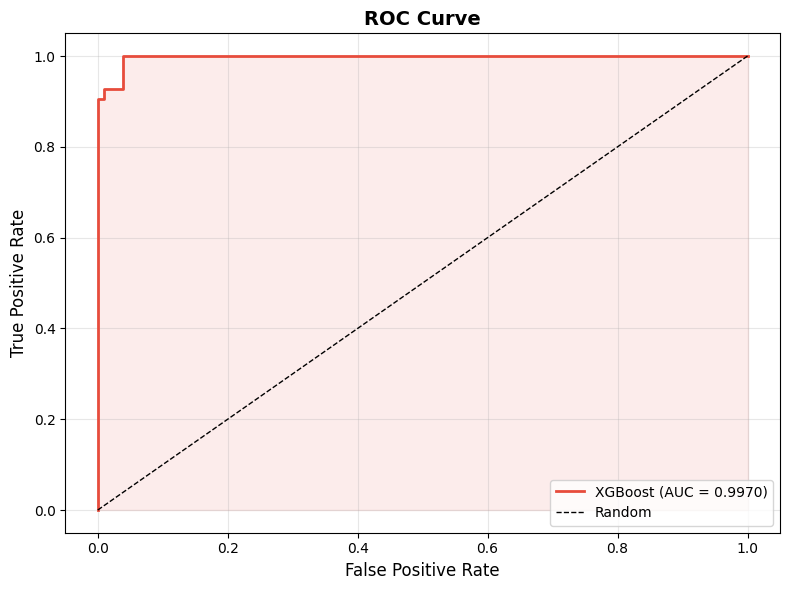

In [4]:
plt.figure(figsize=(8, 6))

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, color='#e74c3c', linewidth=2,
         label=f'XGBoost (AUC = {auc_score:.4f})')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

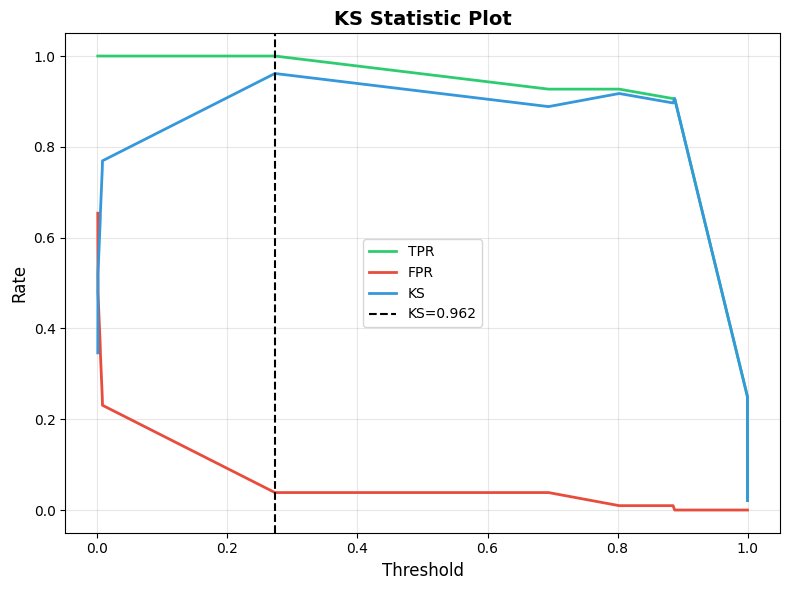

In [6]:
plt.figure(figsize=(8, 6))

ks_values = tpr[:-1] - fpr[:-1]

plt.plot(thresholds[:-1], tpr[:-1],
         color='#2ecc71', linewidth=2, label='TPR')

plt.plot(thresholds[:-1], fpr[:-1],
         color='#e74c3c', linewidth=2, label='FPR')

plt.plot(thresholds[:-1], ks_values,
         color='#3498db', linewidth=2, label='KS')

ks_idx = np.argmax(ks_values)

ks_threshold = thresholds[:-1][ks_idx]

plt.axvline(x=ks_threshold,
            color='black',
            linestyle='--',
            label=f'KS={ks_values[ks_idx]:.3f}')

plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Rate', fontsize=12)
plt.title('KS Statistic Plot', fontsize=14, fontweight='bold')

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted_Prob': y_prob
})

results_df = results_df.sort_values(
    'Predicted_Prob', ascending=False
).reset_index(drop=True)

results_df['Decile'] = pd.qcut(
    results_df.index, 
    q=10, 
    labels=range(1, 11)
)

decile_df = results_df.groupby('Decile').agg(
    Total=('Actual', 'count'),
    Bad=('Actual', 'sum'),
    Min_Prob=('Predicted_Prob', 'min'),
    Max_Prob=('Predicted_Prob', 'max')
).reset_index()

decile_df['Good'] = decile_df['Total'] - decile_df['Bad']
decile_df['Bad_Rate'] = (decile_df['Bad'] / decile_df['Total'] * 100).round(2)

print("=== Decile Analysis ===")
print(decile_df.to_string(index=False))

=== Decile Analysis ===
Decile  Total  Bad  Min_Prob  Max_Prob  Good  Bad_Rate
     1     20   20  0.999787  0.999918     0     100.0
     2     20   20  0.999415  0.999782     0     100.0
     3     20   20  0.995211  0.999398     0     100.0
     4     20   20  0.968356  0.995111     0     100.0
     5     20   16  0.273007  0.961390     4      80.0
     6     20    0  0.007764  0.206864    20       0.0
     7     20    0  0.001359  0.007391    20       0.0
     8     20    0  0.000573  0.001065    20       0.0
     9     20    0  0.000277  0.000555    20       0.0
    10     20    0  0.000089  0.000275    20       0.0


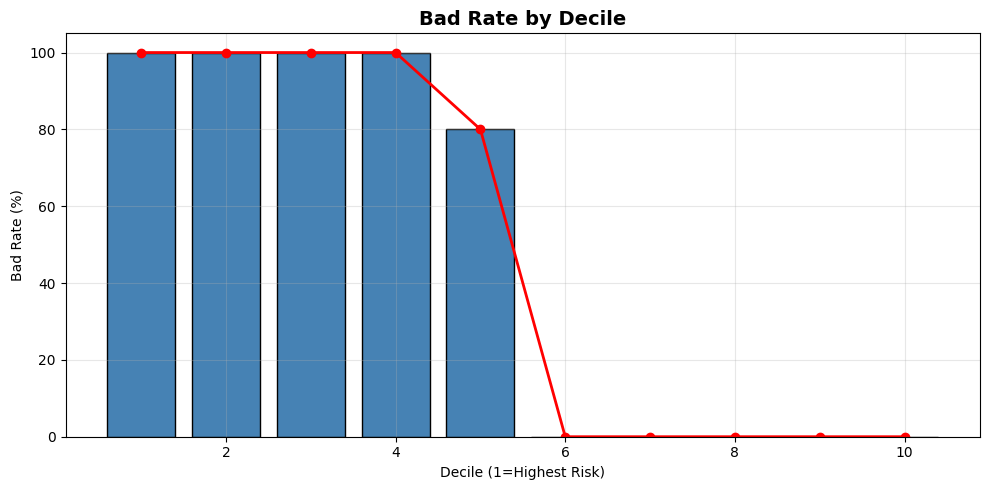

In [8]:
plt.figure(figsize=(10, 5))

plt.bar(decile_df['Decile'], decile_df['Bad_Rate'],
        color='steelblue', edgecolor='black')
plt.plot(decile_df['Decile'], decile_df['Bad_Rate'],
         color='red', marker='o', linewidth=2)

plt.title('Bad Rate by Decile', fontsize=14, fontweight='bold')
plt.xlabel('Decile (1=Highest Risk)')
plt.ylabel('Bad Rate (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Running SHAP analysis...


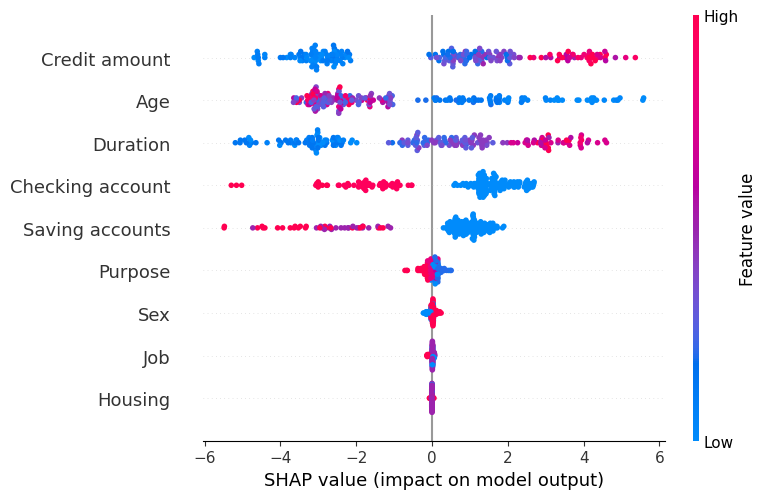

<Figure size 640x480 with 0 Axes>

In [9]:
print("Running SHAP analysis...")

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, 
                  feature_names=X_test.columns.tolist(),
                  show=True)
plt.tight_layout()

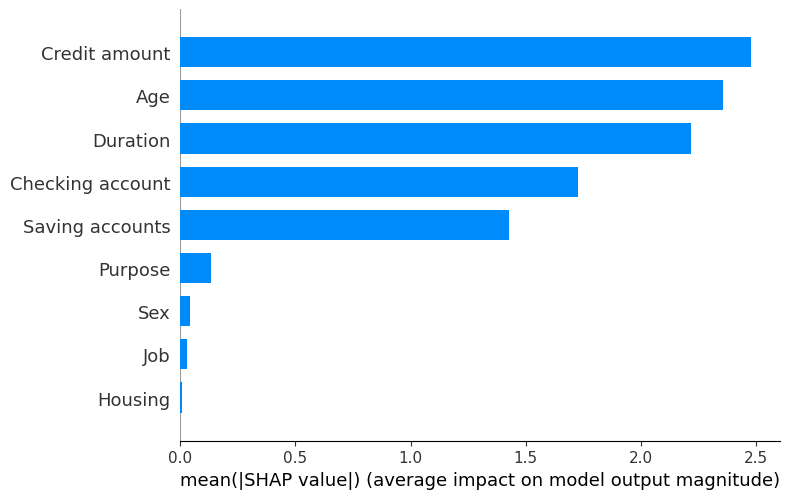

In [10]:
shap.summary_plot(shap_values, X_test,
                  feature_names=X_test.columns.tolist(),
                  plot_type='bar',
                  show=True)

In [11]:
print("=" * 50)
print("     FINAL EVALUATION SUMMARY")
print("=" * 50)
print(f"\nBest Model    : XGBoost")
print(f"Accuracy      : {acc*100:.2f}%")
print(f"AUC Score     : {auc:.4f}")
print(f"Gini          : {gini:.4f}")
print(f"KS Statistic  : {ks_stat*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Good Credit', 'Bad Credit']))
print("=" * 50)
print("Next Step: Build Streamlit App!")
print("=" * 50)

     FINAL EVALUATION SUMMARY

Best Model    : XGBoost
Accuracy      : 97.00%
AUC Score     : 0.9970
Gini          : 0.9940
KS Statistic  : 96.15%

Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.98      0.96      0.97       104
  Bad Credit       0.96      0.98      0.97        96

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200

Next Step: Build Streamlit App!
